In [5]:
# creating students.csv file

data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as f:
    f.write(data)

print("students.csv file created")

students.csv file created


In [6]:
#--------------Task: 1-------------------

import pandas as pd

# reading the file
df = pd.read_csv("students.csv")

# checking first few rows
print(df.head())

# checking shape and types
print("Shape:", df.shape)
print(df.dtypes)

# basic statistics
print(df.describe())

# count of pass/fail students
print(df['passed'].value_counts())

# average subject scores for pass and fail
subjects = ['math','science','english','history','pe']

print("Average for Pass students:")
print(df[df['passed']==1][subjects].mean())

print("Average for Fail students:")
print(df[df['passed']==0][subjects].mean())

# finding best student overall
df['avg'] = df[subjects].mean(axis=1)
top_student = df.loc[df['avg'].idxmax()]

print("Top student is:", top_student['name'])

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
Shape: (15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.0

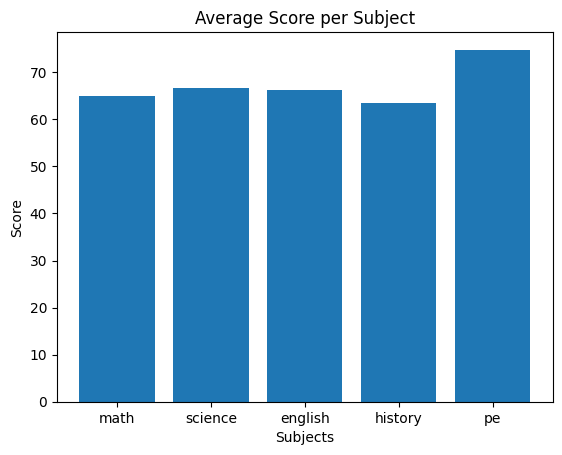

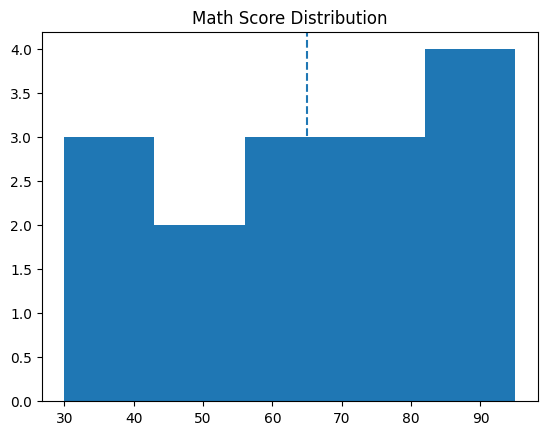

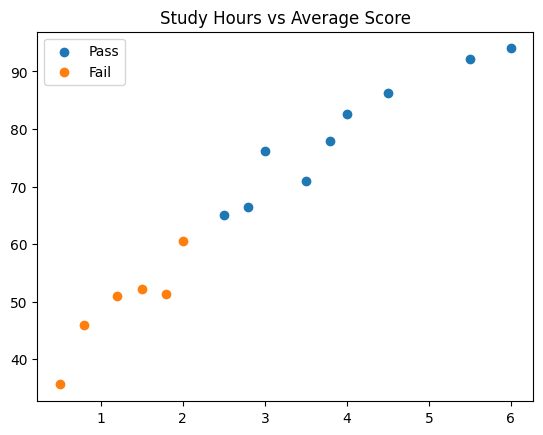

/tmp/ipykernel_10879/2818472080.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


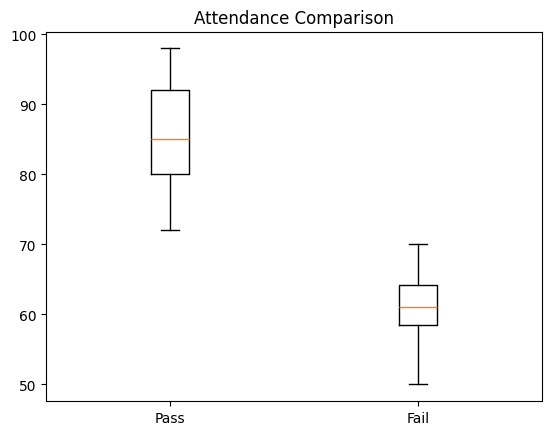

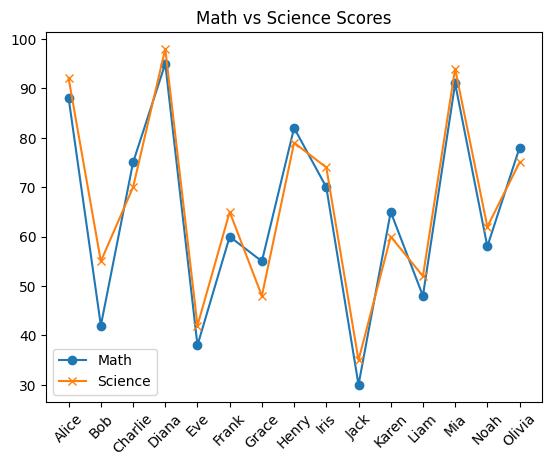

In [7]:
#----------------Task: 2-------------------

import matplotlib.pyplot as plt

# creating avg_score column for later use
df['avg_score'] = df[subjects].mean(axis=1)

# 1. Bar chart
plt.figure()
plt.bar(subjects, df[subjects].mean())
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

# 2. Histogram
plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Score Distribution")
plt.savefig("plot2_hist.png")
plt.show()

# 3. Scatter plot
plt.figure()
pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.legend()
plt.title("Study Hours vs Average Score")
plt.savefig("plot3_scatter.png")
plt.show()

# 4. Box plot
plt.figure()
plt.boxplot([
    pass_df['attendance_pct'],
    fail_df['attendance_pct']
], labels=['Pass','Fail'])

plt.title("Attendance Comparison")
plt.savefig("plot4_box.png")
plt.show()

# 5. Line plot
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.legend()
plt.title("Math vs Science Scores")
plt.savefig("plot5_line.png")
plt.show()

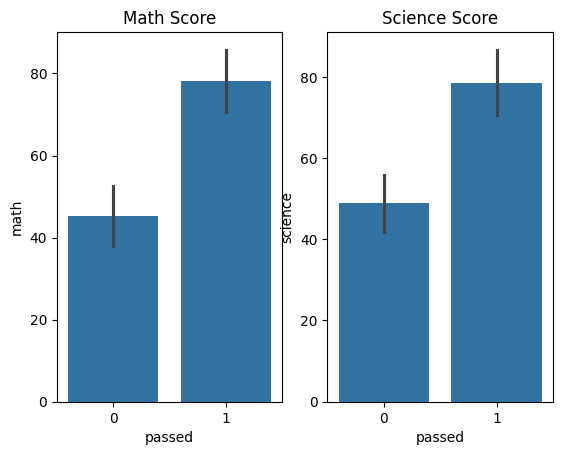

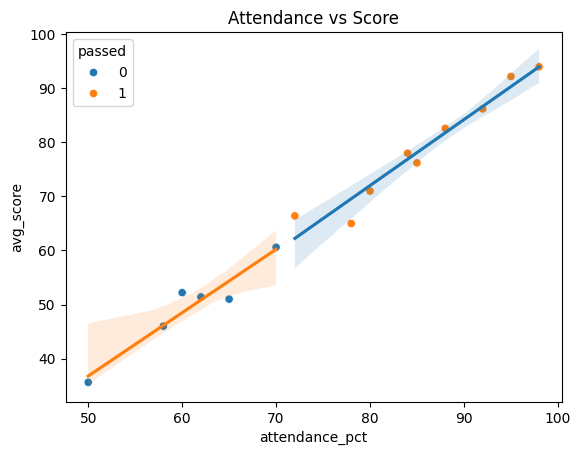

In [8]:
#-----------------Task: 3-------------------

import seaborn as sns

# bar plot using seaborn
plt.figure()

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math Score")

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science Score")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

# scatter with regression
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score', scatter=False)

sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score', scatter=False)

plt.title("Attendance vs Score")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# my observation
# seaborn was easier to use for grouped data
# matplotlib needed more lines of code

Training Accuracy: 1.0
Test Accuracy: 1.0

Student-wise Predictions:

Jack → Actual: 0, Predicted: 0 (✅ correct)
Liam → Actual: 0, Predicted: 0 (✅ correct)
Alice → Actual: 1, Predicted: 1 (✅ correct)

Feature Importance (sorted):

english : 0.8125127982724648
attendance_pct : 0.521876340433209
study_hours_per_day : 0.4844326627100155
pe : 0.47497406284967797
math : 0.43794393086873595
science : 0.3230097624690249
history : 0.26292892629062437


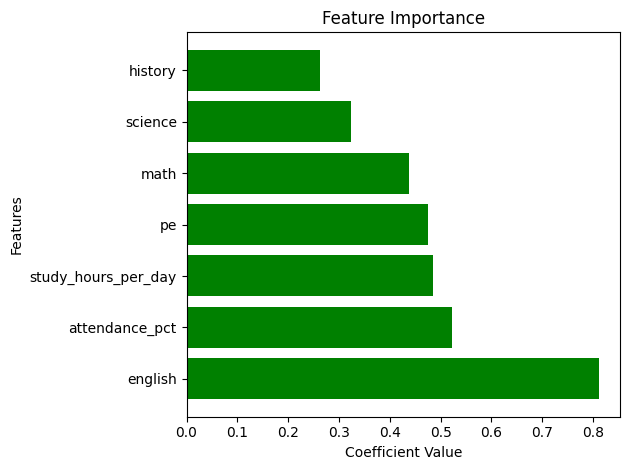


New Student Prediction: PASS
Prediction probability: [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
#------------------Task: 4-----------------------

import pandas as pd
import matplotlib.pyplot as plt

# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("students.csv")


# -------------------------------
# Prepare features and target
# -------------------------------
# keeping original df same, just selecting columns for X

X = df[['math','science','english','history','pe',
        'attendance_pct','study_hours_per_day']]

y = df['passed']


# -------------------------------
# Train-test split
# -------------------------------
# 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -------------------------------
# Feature scaling
# -------------------------------
# scaling helps model work better

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------------
# Train model
# -------------------------------
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# training accuracy
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)


# -------------------------------
# Evaluate model
# -------------------------------

y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)


# -------------------------------
# Show predictions student-wise
# -------------------------------

print("\nStudent-wise Predictions:\n")

# getting names using index
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    if actual == pred:
        result = "✅ correct"
    else:
        result = "❌ wrong"

    print(f"{name} → Actual: {actual}, Predicted: {pred} ({result})")


# -------------------------------
# Feature importance
# -------------------------------

# coefficients from model
coeffs = model.coef_[0]
features = X.columns

# pairing feature with coefficient
feature_data = list(zip(features, coeffs))

# sorting by importance (absolute value)
feature_data.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):\n")

for f, c in feature_data:
    print(f, ":", c)


# -------------------------------
# Plot feature importance
# -------------------------------

names = [f for f, c in feature_data]
values = [c for f, c in feature_data]

# green for positive, red for negative
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(names, values, color=colors)

plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()


# -------------------------------
# Predict for new student (bonus)
# -------------------------------

# example student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# scaling same way as training data
new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0]

if prediction == 1:
    print("\nNew Student Prediction: PASS")
else:
    print("\nNew Student Prediction: FAIL")

print("Prediction probability:", prob)